In [150]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline

In [151]:
df = pd.read_csv("uber.csv")

In [152]:
df.shape

(200000, 9)

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [154]:
df.drop(columns=['Unnamed: 0', 'key'],axis=1,inplace=True)

In [155]:
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [156]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,12.500000,-73.967153,40.767158,-73.963659,40.768001,2.000000
max,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [157]:
df.isnull().sum()

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [158]:
df.duplicated().sum()
num_features = df.select_dtypes(exclude='object').columns
cat_features = df.select_dtypes(include='object').columns

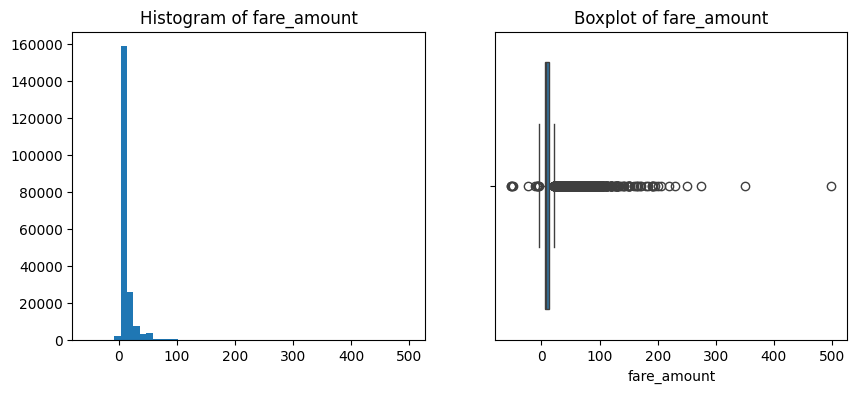

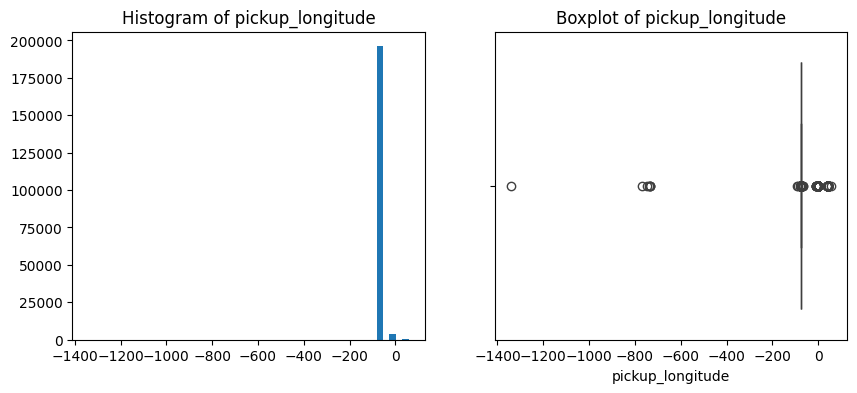

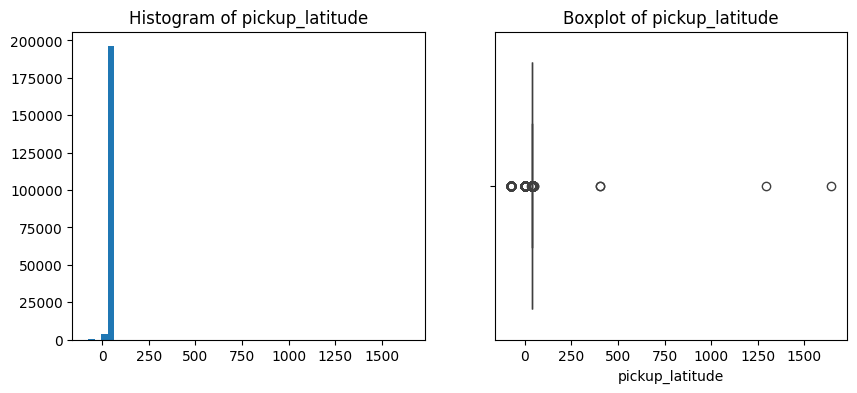

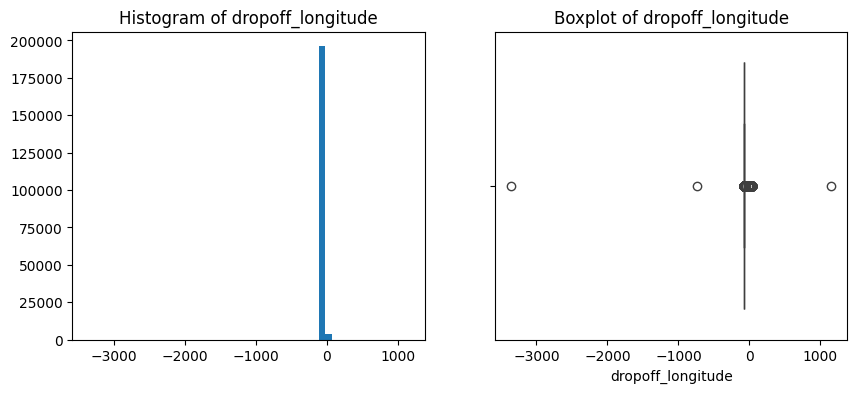

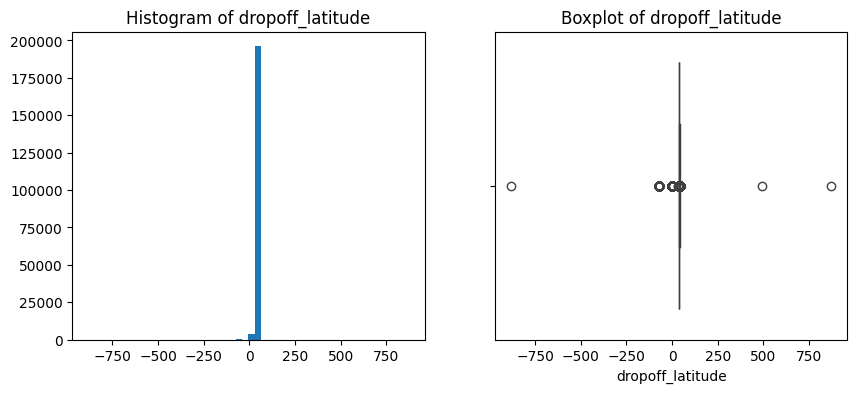

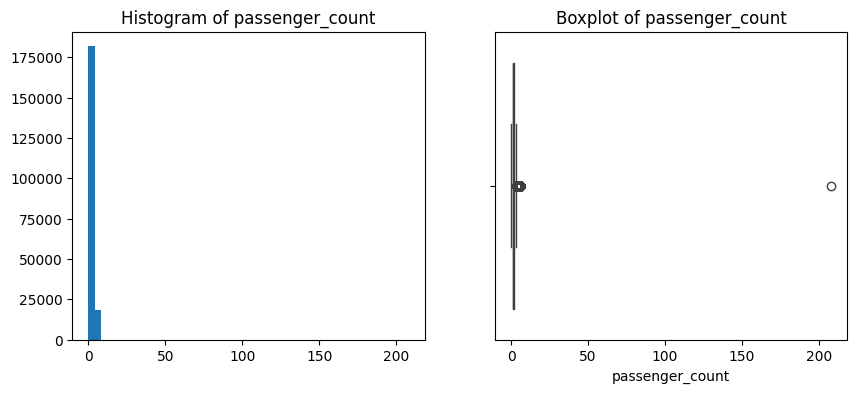

In [159]:
for col in num_features:
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(df[col],bins=50)
    plt.title(f"Histogram of {col}")

    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    
    plt.show()



In [160]:
for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = np.clip(df[col],lower,upper)

In [161]:
df.shape

(200000, 7)

In [162]:
df.columns

Index(['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [163]:
df['passenger_count'].value_counts()

passenger_count
1.0    138425
2.0     29428
3.5     22557
3.0      8881
0.0       709
Name: count, dtype: int64

In [164]:
df['fare_amount'].value_counts()

fare_amount
22.25    17156
6.50      9684
4.50      8247
8.50      7521
5.70      5858
         ...  
11.20        1
15.04        1
13.07        1
7.71         1
10.33        1
Name: count, Length: 252, dtype: int64

In [165]:
df = df[(df['passenger_count'] > 0) & (df['passenger_count']<7)]

In [166]:
df['passenger_count'].value_counts()

passenger_count
1.0    138425
2.0     29428
3.5     22557
3.0      8881
Name: count, dtype: int64

In [167]:
df = df.dropna()

In [168]:
df.isnull().sum()

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [169]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['hour']  = df['pickup_datetime'].dt.hour
df['day']  = df['pickup_datetime'].dt.day
df['month']  = df['pickup_datetime'].dt.month
df['day_of_week']  = df['pickup_datetime'].dt.dayofweek

In [170]:
df.drop(columns=['pickup_datetime'])

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,day_of_week
0,7.50,-73.999817,40.738354,-73.999512,40.723217,1.0,19,7,5,3
1,7.70,-73.994355,40.728225,-73.994710,40.750325,1.0,20,17,7,4
2,12.90,-74.005043,40.740770,-73.962565,40.772647,1.0,21,24,8,0
3,5.30,-73.976124,40.790844,-73.965316,40.803349,3.0,8,26,6,4
4,16.00,-73.929786,40.744085,-73.973082,40.761247,3.5,17,28,8,3
...,...,...,...,...,...,...,...,...,...,...
199995,3.00,-73.987042,40.739367,-73.986525,40.740297,1.0,10,28,10,6
199996,7.50,-73.984722,40.736837,-74.006672,40.739620,1.0,1,14,3,4
199997,22.25,-73.986017,40.756487,-73.922036,40.692588,2.0,0,29,6,0
199998,14.50,-73.997124,40.725452,-73.983215,40.695416,1.0,14,20,5,2


In [171]:
def haversine(lat1,lon1,lat2,lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1))*np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c
df['distance'] = haversine(
    df['pickup_latitude'],df['pickup_longitude'],
    df['dropoff_latitude'],df['dropoff_longitude']
)

In [172]:
df['distance'].describe()


count    199291.000000
mean          2.795865
std           2.236392
min           0.000000
25%           1.196697
50%           2.091517
75%           3.735277
max          17.350348
Name: distance, dtype: float64

<Axes: xlabel='distance', ylabel='fare_amount'>

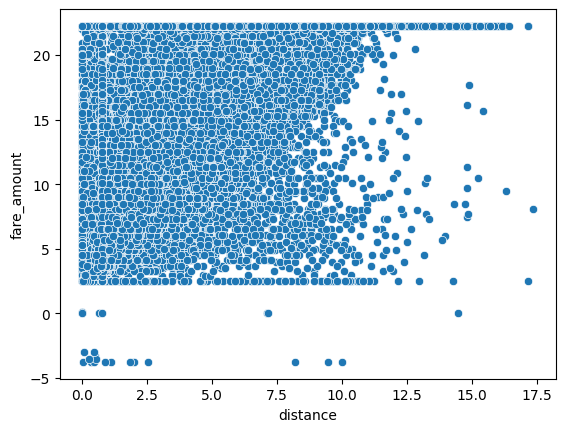

In [173]:
sns.scatterplot(x=df['distance'],y=df['fare_amount'])

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199291 entries, 0 to 199999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   fare_amount        199291 non-null  float64            
 1   pickup_datetime    199291 non-null  datetime64[ns, UTC]
 2   pickup_longitude   199291 non-null  float64            
 3   pickup_latitude    199291 non-null  float64            
 4   dropoff_longitude  199291 non-null  float64            
 5   dropoff_latitude   199291 non-null  float64            
 6   passenger_count    199291 non-null  float64            
 7   hour               199291 non-null  int32              
 8   day                199291 non-null  int32              
 9   month              199291 non-null  int32              
 10  day_of_week        199291 non-null  int32              
 11  distance           199291 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(

In [175]:
df.drop(columns=['pickup_datetime','pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude','hour','day','month','day_of_week'],axis=1,inplace=True)

In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199291 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   fare_amount      199291 non-null  float64
 1   passenger_count  199291 non-null  float64
 2   distance         199291 non-null  float64
dtypes: float64(3)
memory usage: 6.1 MB


In [177]:
df

,fare_amount,passenger_count,distance
0,7.50,1.0,1.683323
1,7.70,1.0,2.457590
2,12.90,1.0,5.036377
3,5.30,3.0,1.661683
4,16.00,3.5,4.116083
...,...,...,...
199995,3.00,1.0,0.112210
199996,7.50,1.0,1.875050
199997,22.25,2.0,8.919342
199998,14.50,1.0,3.539715


In [178]:
df.corr()

,fare_amount,passenger_count,distance
fare_amount,1.000000,0.014659,0.786429
passenger_count,0.014659,1.000000,0.009639
distance,0.786429,0.009639,1.000000


In [179]:
X = df[['distance']]
y = df[['fare_amount']]

In [180]:
from sklearn.model_selection import train_test_split 
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.4,random_state=42)

In [181]:
X_train.shape , X_test.shape , y_train.shape, y_test.shape

((119574, 1), (79717, 1), (119574, 1), (79717, 1))

In [182]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [183]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
model = LinearRegression()
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)


In [184]:
print("mean squared error" ,mean_absolute_error(y_test,y_pred))
print("r2_score" ,r2_score(y_test,y_pred))
print(" mean_absolute_errore" , mean_absolute_error(y_test,y_pred))

mean squared error 2.3105841449314455
r2_score 0.6168894515081154
 mean_absolute_errore 2.3105841449314455


In [188]:
import pickle
pickle.dump(model , open("model.pkl","wb"))